# 011 Complete Species Data
Use complete set of chromosomes from a single species, and assocaited annotations.


In [1]:
%%bash
curl -sLO http://ftp.ensemblgenomes.org/pub/metazoa/release-56/fasta/caenorhabditis_elegans/dna/Caenorhabditis_elegans.WBcel235.dna.chromosome.I.fa.gz
ls *.gz

Caenorhabditis_elegans.WBcel235.dna.chromosome.I.fa.gz


In [1]:
import gzip
from Bio import SeqIO
from gabi import utils as gu

file = "Caenorhabditis_elegans.WBcel235.dna.chromosome.I.fa.gz"
species = "Caenorhabditis_elegans"

seqs = []
with gzip.open(file, "rt") as handle:
    for record in SeqIO.parse(handle, "fasta"):
        seqs.append(record)

seq = seqs[0]

In [2]:
print(len(seq.seq))
seq

15072434


SeqRecord(seq=Seq('GCCTAAGCCTAAGCCTAAGCCTAAGCCTAAGCCTAAGCCTAAGCCTAAGCCTAA...GGC'), id='I', name='I', description='I dna:chromosome chromosome:WBcel235:I:1:15072434:1 REF', dbxrefs=[])

In [14]:
# Encode the seq
from gabi import encodings as ge
from bitstring import Bits
from bientropy import bien, tbien
import multiprocess as mp
import time
import pickle
from itertools import islice
import seaborn as sns
%matplotlib
import matplotlib.pyplot as plt

In [5]:
?tbien

Docstring:
tbien(bits)

The logarithmic weighting BiEntropy, or TBiEn for short, gives greater
weight to the higher binary derivatives. As a result, has a slightly faster
runtime because the weights tend to be smaller than for BiEn.

This algorithm evaluates the order and disorder of a binary string of
length n in O(n^2) time using O(n) memory.

Parameters
----------
bits : bytes object or bitstring-like object
    the input bitstring on which to operate; this function can accept a
    Python bytes string or bitstring object (any object with a tobytes()
    method that returns a byte string and a len() method that returns the
    length in bits)

Returns
-------
float
    the TBiEntropy of the input
Type:      builtin_function_or_method

In [87]:
gcme = gu.encode(seq.seq, ge.GCME)
gcme_len = len(gcme['seq'])
print("gcme_len:", gcme_len)
window_size = gcme['bits'] * 10000 # (2) * 10000
#step=gcme['bits']
step=100

gcme_windows = gu.window_idx(gcme_len, window_size, step=step)


gcme_len: 30144868


In [88]:
#def
#res = []
#for w in gcme_windows:
    #print(w)
#    chunk = gcme["seq"][w[0]:w[1]]
#    b = Bits(chunk)
    #print("Got", b.count(0), "zeros and", b.count(1), "ones")
#    e = tbien(b)
    #print("Log-weighted BiEntropy:", e)
#    res.append( (e, w) )
    #break
    
#gcme

#len(res)

In [89]:
def w_bien(w):
    #print(w)
    chunk = gcme["seq"][w[0]:w[1]]
    b = Bits(chunk)
    #print("Got", b.count(0), "zeros and", b.count(1), "ones")
    e = tbien(b)
    #print("Log-weighted BiEntropy:", e)
    #print(".", end="")
    return (e, w)

In [90]:
max_obs = 0
start = time.time()
with mp.Pool(processes=4) as pool:
    if max_obs > 0:
        res = pool.map(w_bien, islice(gcme_windows, max_obs))
    else:
        res = pool.map(w_bien, gcme_windows)

duration = time.time() - start

#print("")
print("processed", len(res), "windows in", duration / 60, "minutes")

processed 301249 windows in 13.570443228880565 minutes


In [91]:
res[0]

(0.9995595197446446, (0, 20000))

In [92]:
pklfile = f"data/{species}_{seq.name}_L{len(res)}_W{window_size}_S{step}_gcme.pkl"
with open(pklfile, "wb") as file:  # "wb" means write-binary
    pickle.dump(res, file)

In [93]:
#with open(pklfile, "rb") as file:  # "rb" means read-binary
#    loaded_data = pickle.load(file)

In [94]:
len(res)

301249

In [95]:
data = [x[0] for x in res]
len(data)

301249

In [102]:
import numpy as np

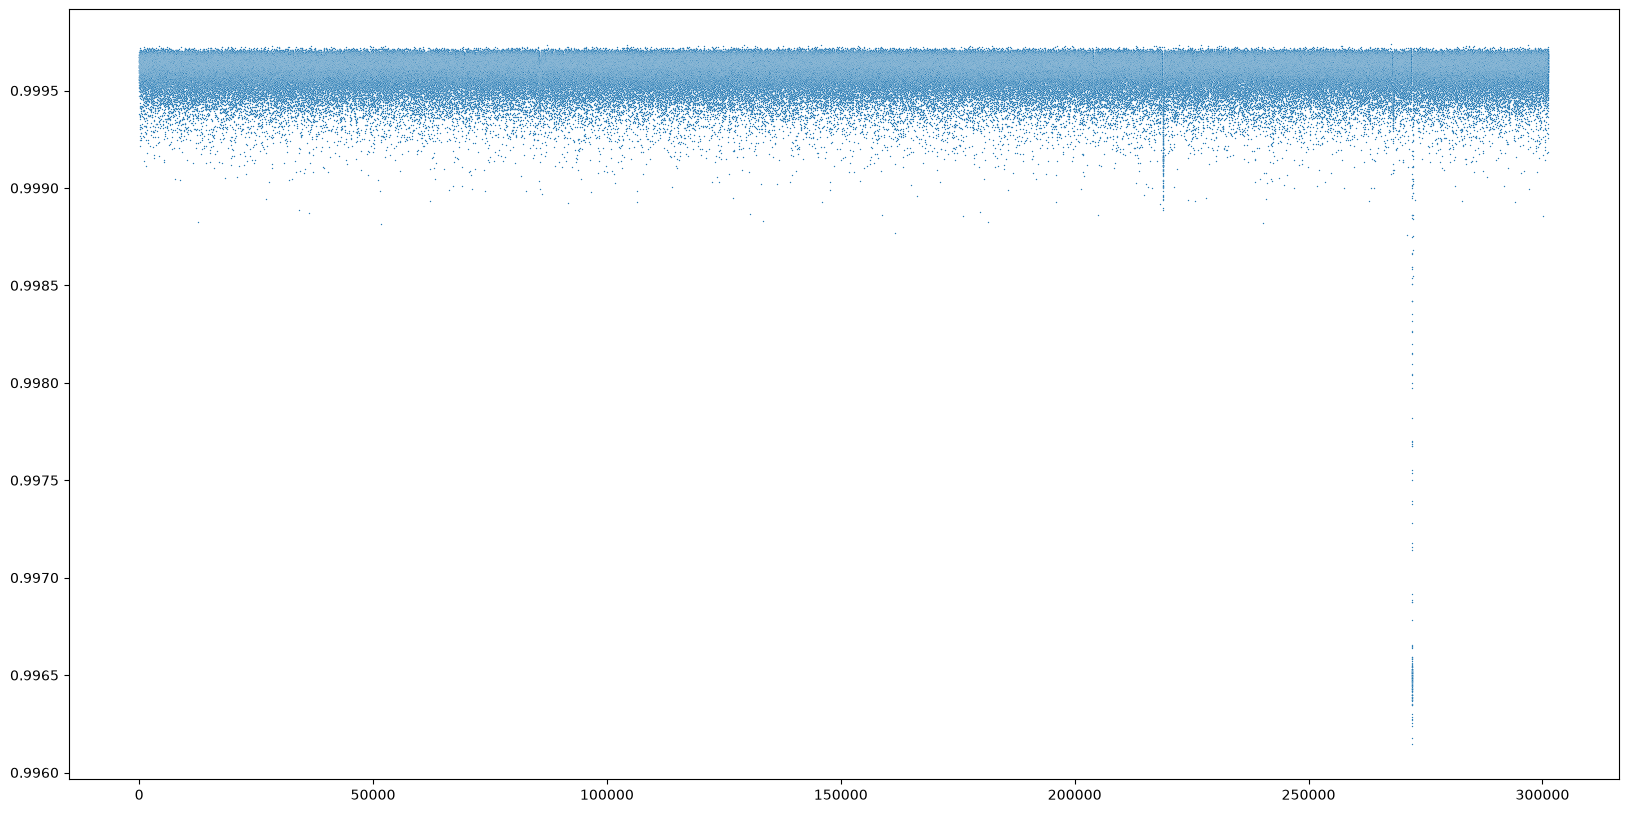

In [116]:
plt.figure(figsize=(20,10))
#ax = sns.scatterplot(data=[np.log10(1+x) for x in data], s=1)
ax = sns.scatterplot(data=data, s=1)

#ax.set_yscale("log")  # Change Y-axis to log scale

In [118]:
[x for x in res if x[0] < 0.997]

[(0.9968732254910518, (27207100, 27227100)),
 (0.9968752499099967, (27207300, 27227300)),
 (0.9968831567836858, (27207400, 27227400)),
 (0.996782771755405, (27207500, 27227500)),
 (0.9963024206262144, (27207600, 27227600)),
 (0.9961443382988758, (27207700, 27227700)),
 (0.9966467170263552, (27207800, 27227800)),
 (0.9965886329978912, (27207900, 27227900)),
 (0.9966532115626651, (27208000, 27228000)),
 (0.996580563904164, (27208100, 27228100)),
 (0.9965635866629854, (27208200, 27228200)),
 (0.9966411613170697, (27208300, 27228300)),
 (0.996647604354182, (27208400, 27228400)),
 (0.996594006790638, (27208500, 27228500)),
 (0.9965557963424491, (27208600, 27228600)),
 (0.9964668906559352, (27208700, 27228700)),
 (0.9963768090185526, (27208800, 27228800)),
 (0.9965124163867219, (27208900, 27228900)),
 (0.996506607832403, (27209000, 27229000)),
 (0.9965484992788639, (27209100, 27229100)),
 (0.9965401862392889, (27209200, 27229200)),
 (0.9965936211141014, (27209300, 27229300)),
 (0.99638486000

In [119]:
print( 27207100 /2, "-", 27240500 / 2)

13603550.0 - 13620250.0


In [122]:
region = seq.seq[13603550:13620250]
len(region)

16700

In [123]:
print(region)

TAGAACTACAAACTACAAGATTTGGTGAGCCTCAACCAAAAATTTTTTTTGTTGAGGCTCACACTACAAACTACACGAATTTCTGAGCCTCAACCAAATTTTTTTGGTGAGGCTAAAACTACGAACTACACGAATCTCTGAGCCTCAACCATATTTTTTTTATAATTTGATATTGATTTTAAATACAATTTCCGAATCAAAATTTGAATAACTTCGTTCCAAAATGTTAAAATGGATATTTTTAGTTGAGGCTCACGCTACAAACTACAAAAAAAGTAATTTTCACCGAAAAAGATACTTTAAAATGGCATTTTCAACCAGAAAAATGGATAAATTAAAAAATAACATCTTCAAAATTTCAAAAACTATTGTTGTTTCATAATAAATAAGGGAAAAGAGCACAAAGAAAAACCGTAGAGCCATATCTGGAAATAATTTAAGTCTAAAAAAGGGGGATGCGGGGGAGGAAAAAAAAAATCAATATCACAATAAACGAAAAAAAAAGTAGAGAATTATTTGACGGGGGGAGCATGGGATGAATCACAACCATTTGAAAACAATGGAATTTTTTTTGTTTGAAATCAGTAATAATAATAATAATAATGAAAATAAAGCGAATAATCTAATTTAAATACAAAAGAGCCACACAAAAATGAGAAATTAATCAGAGCTGTGGGGAGCTAGCTTCAAGTGAAATTTTCCGAAATATGGGATTTCTGAGATTCTTCTAGCGCTTCTTGAACAGTTGTTGGTGATTTCGTTTGAAAATTGATTATTCGTCGGAAGAGCTCGGCGAGCAGTTTTCGCATCGTTTGATCTTCGGCCGTTTCAACGAGATCGCAGAGTCTGAAATGAAGTGAATGTATATTTTTCTCTTTTCATATATATATATAGGTTATTTAATATGGATACATGATCATAATAACTATTCGTTAAAATGGTTGTAGTTTGTAGTTTGTATTTTTCAAAAAAAAATTCATTACGATCTACATTTTTGTCA